In [32]:
# Cell 1: Environment Configuration & Libraries Imports
import os
import re
import json
import time
import uuid
from typing import TypedDict, Optional, List, Dict, Any
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from dotenv import load_dotenv
from litellm import completion
from langgraph.graph import StateGraph, START, END

# Import reportlab components for advanced layout
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage, KeepTogether
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors

# Load system environment tokens
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY if GEMINI_API_KEY else ""
os.environ["GROQ_API_KEY"] = GROQ_API_KEY if GROQ_API_KEY else ""


In [33]:
# Cell 2: Database Connectivity & Target Schema Declarations
connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=mes_new;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
    "Encrypt=no;"
    "MARS_Connection=yes;"
)
engine = create_engine("mssql+pyodbc:///?odbc_connect=" + quote_plus(connection_string))

ALLOWED_TABLES = [
    "WorkOrder", "ProductionPlanning", "Machine", 
    "FinishedGood", "Rejected", "Scrap", 
    "ShiftMaster", "OperatorMaster"
]

mes_schema = {
    "WorkOrder": {
        "columns": {
            "WorkOrderId": "int", "WorkOrderNumber": "nvarchar", "MpsId": "int",
            "ProductId": "int", "PlannedQty": "decimal", "CompletedQty": "decimal",
            "UOM": "nvarchar", "DueDate": "datetime2", "PriorityId": "int",
            "RoutingId": "int", "BomId": "int", "MachineId": "int",
            "OperatorId": "int", "ShiftId": "int", "PlannedStart": "datetime2",
            "PlannedEnd": "datetime2", "ActualStart": "datetime2", "ActualEnd": "datetime2",
            "PlannedDurationHours": "decimal", "ActualDurationHours": "decimal",
            "Status": "nvarchar", "CurrentStep": "int", "ProgressPercent": "decimal",
            "HasException": "bit", "ExceptionCount": "int", "CustomerId": "int",
            "CustomerOrderRef": "nvarchar", "BomVersion": "nvarchar", "ReleasedDate": "datetime2",
            "ReleasedBy": "nvarchar", "CancelReasonCode": "nvarchar", "CancelReasonNotes": "nvarchar",
            "CancelledDate": "datetime2", "Notes": "nvarchar", "CreatedBy": "nvarchar",
            "CreatedDate": "datetime2", "UpdatedBy": "nvarchar", "UpdatedDate": "datetime2"
        }
    },
    "Machine": {
        "columns": {
            "MachineId": "int", "MachineName": "nvarchar", "MachineCode": "nvarchar",
            "MachineType": "nvarchar", "Model": "nvarchar", "Status": "nvarchar"
        }
    },
    "OperatorMaster": {
        "columns": {
            "OperatorId": "int", "OperatorCode": "nvarchar", "OperatorName": "nvarchar",
            "Department": "nvarchar", "Status": "nvarchar"
        }
    },
    "ShiftMaster": {
        "columns": {
            "ShiftId": "int", "ShiftCode": "nvarchar", "ShiftName": "nvarchar", "Status": "nvarchar"
        }
    }
}


In [34]:
# Cell 3: Graph State Structure & LLM Wrapper
class AgentState(TypedDict):
    prompt: str
    intent: Optional[str]
    sql_query: Optional[str]
    raw_data: Optional[str]
    full_df: Optional[pd.DataFrame]
    analysis: Optional[str]
    chart_path: Optional[str]
    html_content: Optional[str]
    pdf_path: Optional[str]
    error: Optional[str]
    retry_count: int
    llm_usage: dict
    execution_logs: list

def call_llm(state: dict, system_prompt: str, user_prompt: str):
    model = "gemini/gemini-3.5-flash-lite-lite" if os.getenv("GEMINI_API_KEY") else "groq/llama-3.3-70b-versatile"
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    response = completion(model=model, messages=messages)
    
    usage = getattr(response, "usage", None)
    p_tokens = getattr(usage, "prompt_tokens", 0) if usage else 0
    c_tokens = getattr(usage, "completion_tokens", 0) if usage else 0
    print(f"   [LLM Usage] Prompt: {p_tokens} | Completion: {c_tokens}")
    
    current = state.get("llm_usage") or {"prompt_tokens": 0, "completion_tokens": 0, "calls": 0}
    new_usage = {
        "prompt_tokens": current["prompt_tokens"] + p_tokens,
        "completion_tokens": current["completion_tokens"] + c_tokens,
        "calls": current["calls"] + 1
    }
    return response.choices[0].message.content, new_usage


In [35]:
# Cell 4: Pipeline Node Definitions - Intent & SQL Processing
def intent_node(state: AgentState) -> AgentState:
    t0 = time.time()
    print("-> Classifying Intent")
    prompt = state["prompt"]
    sys_prompt = "You are an AI reporting agent. Classify the user's intent based on their prompt. What kind of report do they want? Return a short summary of the goal."
    intent, llm_usage = call_llm(state, sys_prompt, prompt)
    logs = state.get("execution_logs") or []
    return {"intent": intent, "llm_usage": llm_usage, "execution_logs": logs + [f"intent_node: {time.time()-t0:.2f}s"]}

def sql_generation_node(state: AgentState) -> AgentState:
    t0 = time.time()
    print("-> Generating SQL")
    intent = state.get("intent", state["prompt"])
    error_msg = state.get("error")
    retry_count = state.get("retry_count", 0)
    
    sys_prompt = f"""You are an expert SQL developer for Microsoft SQL Server. 
Generate a READ-ONLY SELECT statement to satisfy the report requirement.
Only use these tables: {ALLOWED_TABLES}

Database Schema:
{mes_schema}

Return ONLY the raw SQL query without markdown code blocks, starting with SELECT.
DO NOT INCLUDE any markdown backticks or block wrappers (like ```sql)."""
    
    user_prompt = f"Requirement: {intent}"
    if error_msg:
        user_prompt += f"\n\nPREVIOUS QUERY FAILED WITH ERROR:\n{error_msg}\n\nPlease fix the query and return the corrected version."
        print(f"   [Retry {retry_count + 1}] Fixing SQL Error...")
        
    sql, llm_usage = call_llm(state, sys_prompt, user_prompt)
    sql = sql.replace("```sql", "").replace("```", "").strip()
    logs = state.get("execution_logs") or []
    return {"sql_query": sql, "retry_count": retry_count, "llm_usage": llm_usage, "execution_logs": logs + [f"sql_generation_node: {time.time()-t0:.2f}s"]}

def sql_execution_node(state: AgentState) -> AgentState:
    t0 = time.time()
    print("-> Executing SQL")
    sql = state.get("sql_query", "").strip()
    print("\n========== GENERATED SQL ==========")
    print(sql)
    print("===================================\n")
    
    logs = state.get("execution_logs") or []
    retry_count = state.get("retry_count", 0)
    
    if not re.match(r"^(SELECT|WITH)\b", sql, re.IGNORECASE):
        return {"error": "Invalid SQL: Only SELECT/WITH queries allowed.", "retry_count": retry_count, "execution_logs": logs}
        
    clean_sql = sql.rstrip(";")
    if ";" in clean_sql:
         return {"error": "Invalid SQL: Multiple statements not allowed.", "retry_count": retry_count, "execution_logs": logs}
         
    try:
        df = pd.read_sql_query(clean_sql, engine)
        df_head = df.head(100).to_csv(index=False)
        print(f"   [SQL] Query returned {len(df)} rows.")
        return {"raw_data": df_head, "full_df": df, "error": "", "execution_logs": logs + [f"sql_execution_node: {time.time()-t0:.2f}s"]}
    except Exception as e:
        return {"error": str(e), "retry_count": retry_count, "execution_logs": logs + [f"sql_execution_node (error): {time.time()-t0:.2f}s"]}


In [36]:
# Cell 5: Pipeline Node Definitions - Data Analysis & Visualizations
def analysis_node(state: AgentState) -> AgentState:
    t0 = time.time()
    print("-> Analyzing Data & Creating JSON for PDF")
    logs = state.get("execution_logs") or []
    if state.get("error"):
        return {"execution_logs": logs + [f"analysis_node (skipped): {time.time()-t0:.2f}s"]}
        
    raw_data = state.get("raw_data", "")
    prompt = state["prompt"]
    
    sys_prompt = """You are a manufacturing data analyst.
Based on the raw CSV data and user request, provide a HIGHLY DETAILED JSON response for a PDF report.
Extract actual technical details like BOM Version, Routing, Dates, Priority, and Machine Codes.
The JSON MUST exactly follow this format:
{
  "executive_summary": "Detailed 3-4 sentence operational summary of the active work orders.",
  "production_analysis": "Technical analysis comparing planned versus completed targets across assets.",
  "production_table": [
    {"wo_num": "WO202608...", "bom": "V1.0", "priority": "High", "target": "1000", "actual": "950", "status": "On Track"}
  ],
  "configuration_table": [
    {"wo_num": "WO202608...", "machine": "ABS-01", "operator": "John Doe", "shift": "Shift A", "start": "2026-08-11", "end": "2026-08-12"}
  ],
  "oee_overview": "Analysis of machine status, exceptions, and utilization benchmarks.",
  "oee_table": [
    {"machine": "ABS-01", "utilization": "100.0%", "exceptions": "0", "status": "Optimal"}
  ],
  "shift_analysis": "Detailed shift allocation, operator coverage and exception analysis.",
  "scrap_drivers": "Root cause analysis of any canceled orders, missing configuration, or bottlenecks."
}
For statuses, use exactly one of: "Optimal", "On Track", "Needs Review", "Below Target".
Return ONLY valid JSON without markdown formatting blocks."""

    analysis_text, llm_usage = call_llm(state, sys_prompt, f"User Request: {prompt}\n\nData:\n{raw_data}")
    analysis_text = analysis_text.replace("```json", "").replace("```", "").strip()
    return {"analysis": analysis_text, "llm_usage": llm_usage, "execution_logs": logs + [f"analysis_node: {time.time()-t0:.2f}s"]}

def chart_generation_node(state: AgentState) -> AgentState:
    t0 = time.time()
    print("-> Generating Technical Comparison Charts")
    logs = state.get("execution_logs") or []
    if state.get("error") or "full_df" not in state:
        return {"execution_logs": logs + [f"chart_generation_node (skipped): {time.time()-t0:.2f}s"]}
        
    df = state["full_df"]
    chart_paths = []
    os.makedirs("reports", exist_ok=True)
    plt.style.use('bmh')
    
    try:
        if df is not None and not df.empty:
            # Force numeric data formatting for plotting targets
            df['PlannedQty'] = pd.to_numeric(df['PlannedQty'], errors='coerce').fillna(0)
            df['CompletedQty'] = pd.to_numeric(df['CompletedQty'], errors='coerce').fillna(0)
            df['WorkOrderNumber'] = df['WorkOrderNumber'].astype(str)
            
            # Chart 1: Target vs Actual Performance Bar Chart (Highly Functional)
            fig, ax = plt.subplots(figsize=(6.5, 3.2))
            x_indexes = range(len(df))
            width = 0.35
            
            ax.bar([x - width/2 for x in x_indexes], df['PlannedQty'], width=width, label='Planned Qty', color='#4299e1')
            ax.bar([x + width/2 for x in x_indexes], df['CompletedQty'], width=width, label='Actual Completed', color='#2b5c8f')
            
            ax.set_title("Production Target Achievement by Work Order", fontsize=10, fontweight='bold', color='#1a365d')
            ax.set_xticks(x_indexes)
            ax.set_xticklabels(df['WorkOrderNumber'], rotation=10, fontsize=8, ha='right')
            ax.legend(fontsize=8)
            plt.tight_layout()
            
            path1 = os.path.abspath(f"reports/chart1_{uuid.uuid4().hex[:8]}.png")
            plt.savefig(path1, dpi=300, bbox_inches='tight')
            plt.close(fig)
            chart_paths.append(path1)
            
            # Chart 2: Order Progress Status Pie Chart
            if 'Status' in df.columns:
                status_counts = df['Status'].value_counts()
                fig2, ax2 = plt.subplots(figsize=(3.5, 3.5))
                ax2.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=['#2b5c8f', '#4299e1', '#bee3f8', '#cbd5e0'])
                ax2.add_artist(plt.Circle((0,0), 0.70, fc='white')) # Donut style
                ax2.set_title("Work Order Status Split", fontsize=10, fontweight='bold', color='#1a365d')
                plt.tight_layout()
                
                path2 = os.path.abspath(f"reports/chart2_{uuid.uuid4().hex[:8]}.png")
                plt.savefig(path2, dpi=300, bbox_inches='tight')
                plt.close(fig2)
                chart_paths.append(path2)
                
    except Exception as e:
        print(f"Chart generation error: {e}")
        
    return {"chart_path": json.dumps(chart_paths), "execution_logs": logs + [f"chart_generation_node: {time.time()-t0:.2f}s"]}


In [37]:
# Cell 6: Pipeline Node Definitions - Component Processing & Pure Python ReportLab PDF Compilation
def html_generation_node(state: AgentState) -> AgentState:
    return {"html_content": state.get("analysis", "{}")}

def pdf_compilation_node(state: AgentState) -> AgentState:
    t0 = time.time()
    print("-> Compiling Detailed Industrial Report via ReportLab Pure Python Engine")
    logs = state.get("execution_logs") or []
    if state.get("error") or not state.get("analysis"):
        return {"execution_logs": logs + [f"pdf_compilation_node (skipped): {time.time()-t0:.2f}s"]}
        
    os.makedirs("reports", exist_ok=True)
    pdf_filename = f"reports/premium_report_{uuid.uuid4().hex[:8]}.pdf"
    pdf_path = os.path.abspath(pdf_filename)
    
    try:
        data = json.loads(state.get("analysis", "{}"))
        charts = json.loads(state.get("chart_path", "[]"))
    except:
        data, charts = {}, []

    try:
        doc = SimpleDocTemplate(pdf_path, pagesize=letter, leftMargin=36, rightMargin=36, topMargin=36, bottomMargin=36)
        story = []
        
        styles = getSampleStyleSheet()
        title_style = ParagraphStyle('DocTitle', parent=styles['Heading1'], fontSize=18, textColor=colors.HexColor('#1A365D'), spaceAfter=2)
        subtitle_style = ParagraphStyle('DocSub', parent=styles['Normal'], fontSize=8, textColor=colors.HexColor('#718096'), spaceAfter=12)
        h2_style = ParagraphStyle('SectionHeading', parent=styles['Heading2'], fontSize=12, textColor=colors.HexColor('#2B6CB0'), spaceBefore=12, spaceAfter=6, keepWithNext=True)
        body_style = ParagraphStyle('BodyTextCustom', parent=styles['Normal'], fontSize=9, textColor=colors.HexColor('#2D3748'), leading=13)
        th_style = ParagraphStyle('TableHeader', parent=styles['Normal'], fontSize=8.5, fontName='Helvetica-Bold', textColor=colors.HexColor('#4A5568'))
        td_style = ParagraphStyle('TableCell', parent=styles['Normal'], fontSize=8.5, textColor=colors.HexColor('#2D3748'))
        
        # Document Headers
        story.append(Paragraph("MES PRODUCTION METRICS & CONFIGURATION REPORT", title_style))
        story.append(Paragraph("Facility: Manufacturing Plant System Sync | Layer: Agentic Enterprise Core | CONFIDENTIAL", subtitle_style))
        
        # Executive Summary Box
        story.append(Paragraph("<b>Executive Analytics Summary:</b>", h2_style))
        story.append(Paragraph(data.get("executive_summary", ""), body_style))
        story.append(Spacer(1, 10))
        
        # Section 1: Order Progress & Target Execution
        story.append(Paragraph("1. Order Progress & Target Quantity Execution", h2_style))
        story.append(Paragraph(f"<b>Metrics Insight:</b> {data.get('production_analysis', '')}", body_style))
        story.append(Spacer(1, 6))
        
        # Production Quantities Table
        prod_content = [[Paragraph("Work Order", th_style), Paragraph("BOM Ver", th_style), Paragraph("Priority", th_style), Paragraph("Target Qty", th_style), Paragraph("Actual Qty", th_style), Paragraph("Status", th_style)]]
        for r in data.get("production_table", []):
            prod_content.append([
                Paragraph(str(r.get('wo_num','')), td_style), Paragraph(str(r.get('bom','')), td_style),
                Paragraph(str(r.get('priority','')), td_style), Paragraph(str(r.get('target','')), td_style),
                Paragraph(str(r.get('actual','')), td_style), Paragraph(f"<b>{r.get('status','')}</b>", td_style)
            ])
        
        t1 = Table(prod_content, colWidths=[120, 60, 60, 80, 80, 100])
        t1.setStyle(TableStyle([
            ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#EDF2F7')),
            ('BOTTOMPADDING', (0,0), (-1,0), 6),
            ('TOPPADDING', (0,0), (-1,0), 6),
            ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#E2E8F0')),
            ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
        ]))
        story.append(t1)
        
        # Visual Charts Placement (Side by Side Grid representation or sequential stacked)
        if len(charts) > 0 and os.path.exists(charts[0]):
            story.append(Spacer(1, 10))
            story.append(RLImage(charts[0], width=340, height=170))
            
        # Section 2: Technical Configuration Specifications
        story.append(Paragraph("2. Asset Allocation & Work Order Configuration", h2_style))
        config_content = [[Paragraph("Work Order", th_style), Paragraph("Assigned Machine", th_style), Paragraph("Operator Name", th_style), Paragraph("Shift Window", th_style), Paragraph("Planned Start", th_style), Paragraph("Planned End", th_style)]]
        for r in data.get("configuration_table", []):
            config_content.append([
                Paragraph(str(r.get('wo_num','')), td_style), Paragraph(str(r.get('machine','')), td_style),
                Paragraph(str(r.get('operator','')), td_style), Paragraph(str(r.get('shift','')), td_style),
                Paragraph(str(r.get('start','')), td_style), Paragraph(str(r.get('end','')), td_style)
            ])
            
        t2 = Table(config_content, colWidths=[110, 95, 95, 70, 85, 85])
        t2.setStyle(TableStyle([
            ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#EDF2F7')),
            ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#E2E8F0')),
            ('BOTTOMPADDING', (0,0), (-1,-1), 5),
            ('TOPPADDING', (0,0), (-1,-1), 5),
        ]))
        story.append(t2)
        story.append(Spacer(1, 10))
        
        # Section 3: Machine Performance & Resource Efficiency
        story.append(Paragraph("3. Resource Efficiency Profiles & Operational Risks", h2_style))
        story.append(Paragraph(f"<b>OEE Summary:</b> {data.get('oee_overview', '')}", body_style))
        story.append(Spacer(1, 6))
        
        oee_content = [[Paragraph("Machine Asset", th_style), Paragraph("Utilization Rate", th_style), Paragraph("Exception Count", th_style), Paragraph("Status", th_style)]]
        for r in data.get("oee_table", []):
            oee_content.append([
                Paragraph(str(r.get('machine','')), td_style), Paragraph(str(r.get('utilization','')), td_style),
                Paragraph(str(r.get('exceptions','')), td_style), Paragraph(f"<b>{r.get('status','')}</b>", td_style)
            ])
            
        t3 = Table(oee_content, colWidths=[150, 110, 110, 130])
        t3.setStyle(TableStyle([
            ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#EDF2F7')),
            ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#E2E8F0')),
            ('BOTTOMPADDING', (0,0), (-1,-1), 5),
        ]))
        story.append(t3)
        
        # Section 4: Operational Risks Text Blocks
        story.append(Spacer(1, 10))
        story.append(Paragraph(f"<b>Shift & Execution Logs:</b> {data.get('shift_analysis', '')}", body_style))
        story.append(Spacer(1, 4))
        story.append(Paragraph(f"<b>Root Cause & Scrap Drivers:</b> {data.get('scrap_drivers', '')}", body_style))
        
        if len(charts) > 1 and os.path.exists(charts[1]):
            story.append(Spacer(1, 10))
            story.append(RLImage(charts[1], width=160, height=160))
            
        # Build Document
        doc.build(story)
        print(f"-> Production PDF successfully written via pure python: {pdf_path}")
        
        # Clean up chart images from file system
        for path in charts:
            if os.path.exists(path):
                os.remove(path)
                
    except Exception as e:
        print(f"PDF Pure Engine Compiler failed: {e}")
        return {"error": str(e), "execution_logs": logs + [f"pdf_compilation_node (error): {time.time()-t0:.2f}s"]}
        
    return {"pdf_path": pdf_path, "execution_logs": logs + [f"pdf_compilation_node: {time.time()-t0:.2f}s"]}


In [38]:
# Cell 7: Pipeline State Mapping & LangGraph Workflow Generation
def should_retry(state: AgentState) -> str:
    if state.get("error"):
        if state.get("retry_count", 0) < 3:
            return "sql_generation"
        print(" [!] Threshold reached. Skipping execution, sending pipeline error to summary.")
    return "analysis"

workflow = StateGraph(AgentState)

workflow.add_node("intent", intent_node)
workflow.add_node("sql_generation", sql_generation_node)
workflow.add_node("sql_execution", sql_execution_node)
workflow.add_node("analysis", analysis_node)
workflow.add_node("chart_generation", chart_generation_node)
workflow.add_node("html_generation", html_generation_node)
workflow.add_node("pdf_compilation", pdf_compilation_node)

workflow.add_edge(START, "intent")
workflow.add_edge("intent", "sql_generation")
workflow.add_edge("sql_generation", "sql_execution")
workflow.add_conditional_edges("sql_execution", should_retry, {"sql_generation": "sql_generation", "analysis": "analysis"})
workflow.add_edge("analysis", "chart_generation")
workflow.add_edge("chart_generation", "html_generation")
workflow.add_edge("html_generation", "pdf_compilation")
workflow.add_edge("pdf_compilation", END)

app = workflow.compile()


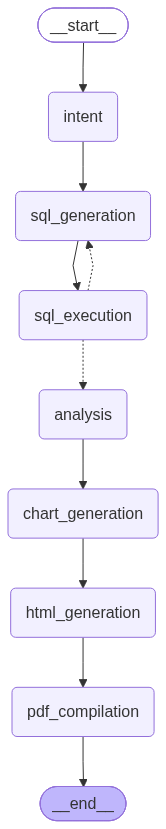

In [39]:
app

In [40]:
# Cell 8: System Trigger & Runtime Initialization Interface
def generate_report(prompt: str):
    print(f"Initializing Report Sequence: {prompt}\n")
    state = {"prompt": prompt, "retry_count": 0}
    
    final_output = None
    for event in app.stream(state):
        for node_name, node_state in event.items():
            final_output = node_state
            
    if final_output and final_output.get("pdf_path"):
        print(f"\nFinal Executive PDF compiled successfully at:\n{final_output.get('pdf_path')}")
    elif final_output and final_output.get("error"):
        print(f"\nPipeline Exception Encountered: {final_output.get('error')}")

# Execution statement
generate_report("generate a report of work orders and tell about complete configuration of it")


Initializing Report Sequence: generate a report of work orders and tell about complete configuration of it

-> Classifying Intent
   [LLM Usage] Prompt: 49 | Completion: 45
-> Generating SQL
   [LLM Usage] Prompt: 555 | Completion: 412
-> Executing SQL

========== GENERATED SQL ==========
SELECT 
    wo.WorkOrderId,
    wo.WorkOrderNumber,
    wo.MpsId,
    wo.ProductId,
    wo.PlannedQty,
    wo.CompletedQty,
    wo.UOM,
    wo.DueDate,
    wo.PriorityId,
    wo.RoutingId,
    wo.BomId,
    wo.PlannedStart,
    wo.PlannedEnd,
    wo.ActualStart,
    wo.ActualEnd,
    wo.PlannedDurationHours,
    wo.ActualDurationHours,
    wo.Status,
    wo.CurrentStep,
    wo.ProgressPercent,
    wo.HasException,
    wo.ExceptionCount,
    wo.CustomerId,
    wo.CustomerOrderRef,
    wo.BomVersion,
    wo.ReleasedDate,
    wo.ReleasedBy,
    wo.CancelReasonCode,
    wo.CancelReasonNotes,
    wo.CancelledDate,
    wo.Notes,
    wo.CreatedBy,
    wo.CreatedDate,
    wo.UpdatedBy,
    wo.UpdatedDate,
   